# Extended Kalman Filter, Multi-Series Forecast

`ssp_v5` fits the multi-series EKF (`kalman_filter_1d_ekf_st`) and stops at the end of the sample.
`ssp_v6` picks the fit up from there and pushes it **past** the sample with
[`forecast_ssp`](../../src/bunobee/models/ssp/forecast.py):

1. hold out the last `HORIZON` days of the sparse panel,
2. fit the `ssp_v5` model on the remaining history (normalisation fitted on the training window only,
   so the holdout stays genuinely out of sample),
3. continue the design matrix with `build_forecast_design`,
4. draw the predictive path with `forecast_ssp` and plot it.

`forecast_ssp` is a *posterior replay*: the filtered state path already lives in the posterior, so the
forecast launches from the last filtered state `a_T = at[:, -1, :]` and walks a driftless random walk
forward, one `N(0, diag(sigma_q**2))` increment per step, per posterior draw:

```
a_{T+h} = a_T + sum_{k=1..h} eta_k        eta_k ~ N(0, diag(sigma_q**2))
a_nat   = where(positivity, exp(exponent * a), a)
mu      = einsum("hij,shj->shi", Z_future, a_nat)
y       = mu + eps                        eps ~ N(0, sigma_h[series]**2)   # noise_embed=True
```

The random walk is why the state band widens with the horizon; `eps` is a horizon-flat slab on top.

**Plots in this notebook**

1. **Forecast fan chart** for one series — observed `y`, in-sample `mu` median, forecast median with
   50% / 90% bands, and the noise-inflated predictive band.
2. **State path** — `plot_states` on the fitted in-sample states.
3. **Multi-series panel** — the same fan chart faceted over all series, confirming that the
   `(sample, time, series)` output plots per series.


## Library and Configs


In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import numpyro
numpyro.set_host_device_count(4)
numpyro.enable_x64(False)

import jax.numpy as jnp
from jax import random
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS

from bunobee.models.ssp import (
    build_forecast_design,
    forecast_ssp,
    plot_states,
    transform_to_ekf_st,
)
from bunobee.models.ssp.kalman_1d_st_ekf import kalman_filter_1d_ekf_st
from bunobee.models.ssp.prior import SspPrior

import jax
print(f"jax {jax.__version__} | numpyro {numpyro.__version__} | devices: {jax.devices()}")


jax 0.8.0 | numpyro 0.20.0 | devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]


In [ ]:
df = pd.read_csv("../resource/sparse/sparse_df.csv", parse_dates=["date"])

media_vars = [
    "ch_1", "ch_2", "ch_3", "ch_4", "ch_5", "ch_6", "ch_7", "ch_8", "ch_9", "ch_10",
    "ch_11", "ch_12", "ch_13",
]
response = "outcome"
trend_vars = ["trend", "yearly", "weekly"]

# Forecast horizon: the last HORIZON days are held out of the fit and used as ground truth.
HORIZON = 28

num_warmup = 50
num_samples = 100
num_chains = 4

# EKF positivity reparameterisation: lambda = exp(k * a) with k = EXPONENT (see ssp_v5).
EXPONENT = 1.0
# Natural-scale reference level for media coefficients; log(0) blows up the a-space transform.
MEDIA_A0_NAT = 0.1

SEED = 42

print(f"horizon: {HORIZON} | mcmc: {num_chains} chains x ({num_warmup} warmup + {num_samples} draws)")
print(f"exponent: {EXPONENT} | media a0 (natural scale): {MEDIA_A0_NAT} | forecast seed: {SEED}")


horizon: 28 | mcmc: 4 chains x (50 warmup + 100 draws)
exponent: 1.0 | media a0 (natural scale): 0.1 | forecast seed: 42


## Data — Train / Holdout Split


In [ ]:
all_vars = media_vars + trend_vars + [response]

dates = sorted(df["date"].unique())
dmas = list(df["dma"].unique())

ds = xr.Dataset(
    {
        v: xr.DataArray(
            df.pivot(index="date", columns="dma", values=v)
              .reindex(index=dates, columns=dmas)
              .values,
            coords={"date": dates, "series": dmas},
            dims=["date", "series"],
        )
        for v in all_vars
    }
)

n_all = len(dates)
n_train = n_all - HORIZON
train_dates = np.array(dates[:n_train])
future_dates = np.array(dates[n_train:])

print(f"{n_all} days x {len(dmas)} series | train: {n_train} | holdout: {HORIZON}")
print(f"train window: {train_dates[0]} .. {train_dates[-1]}")
print(f"holdout window: {future_dates[0]} .. {future_dates[-1]}")


426 days x 14 series | train: 398 | holdout: 28
train window: 2024-11-25 00:00:00 .. 2025-12-27 00:00:00
holdout window: 2025-12-28 00:00:00 .. 2026-01-24 00:00:00


In [ ]:
# Design matrix: [offset (trend + yearly + weekly)] + [13 media channels], same layout as ssp_v5.
# (n_steps, n_series)
y_raw = ds[response].values
# (n_steps, n_series, n_vars) -> sum(-1) -> (n_steps, n_series)
offset = ds[trend_vars].to_array().values.transpose([1, 2, 0]).sum(axis=-1)
# (n_steps, n_series, n_states)
Z_raw = np.concatenate(
    [offset[:, :, None], ds[media_vars].to_array().values.transpose([1, 2, 0])], axis=-1
)

# Mean-normalise per series. The scales come from the TRAINING window only -- using the full sample
# would leak the holdout into the fit.
y_scale = y_raw[:n_train].mean(axis=0)          # (n_series,)
Z_scale = Z_raw[:n_train].mean(axis=0)          # (n_series, n_states)
y_all = y_raw / y_scale
Z_all = Z_raw / Z_scale

y = jnp.asarray(y_all[:n_train])
Z = jnp.asarray(Z_all[:n_train])

# Ground truth for the forecast window: the holdout response, and the design we would have known.
y_holdout = y_all[n_train:]
Z_future_truth = Z_all[n_train:]

n_steps, n_series, n_states = Z.shape
state_names = ["offset"] + media_vars
print("y (train) shape:", y.shape)
print("Z (train) shape:", Z.shape)
print("Z_future_truth shape:", Z_future_truth.shape)


y (train) shape: (398, 14)
Z (train) shape: (398, 14, 14)
Z_future_truth shape: (28, 14, 14)


## Prior

The `ssp_v5` prior, restricted to the training window: an unconstrained `offset` state and 13
positivity-constrained media states, `Beta(2, 10) * scale` on both noise blocks, no time-point anchors
(`a_obs = 0`, `P_obs = inf` everywhere, i.e. a no-op in the filter).


In [ ]:
y_std = np.std(np.asarray(y), axis=0)                                        # (n_series,)
sd_x = ds[media_vars].to_array().values.transpose([1, 2, 0])[:n_train].std(axis=0)   # (n_series, n_media)
sdy = y_std
sdy_over_sdx = y_std[:, None] / sd_x

# Inverse-variance weighted pooling across series: Var(sample std) ~ s**2 / (2 * n_steps), so w ~ 1 / s**2.
w_sdy = 1.0 / sdy ** 2
sdy_ivw = (w_sdy * sdy).sum() / w_sdy.sum()
w_r = 1.0 / sdy_over_sdx ** 2
sdy_over_sdx_ivw = (w_r * sdy_over_sdx).sum(axis=0) / w_r.sum(axis=0)

# No time-point anchors: loc 0 / var inf is zero precision -> the filter passes through untouched.
a_obs = np.zeros((n_steps, n_states))
P_obs = np.full((n_steps, n_states), np.inf)

# Media states are seeded at MEDIA_A0_NAT so transform_to_ekf_st does not take log(0).
a0 = np.concatenate([[1.0], np.full(n_states - 1, MEDIA_A0_NAT)])
P0_diag = np.concatenate([[0.1], np.full(n_states - 1, 0.001)])
positivity = np.array([False] + [True] * len(media_vars))

# sigma_q, compressed to (2,): [offset, shared-media]; mode-matched into a-space by transform_to_ekf_st.
sigma_q_scale_nat = np.array([
    0.05 * float(sdy_ivw),
    0.001 * float(sdy_over_sdx_ivw.mean()),
])

ssp_prior = xr.Dataset(
    {
        "a0":                  (("state",),              a0),
        "P0":                  (("state", "state_dual"), np.diag(P0_diag)),
        "a_obs":               (("time", "state"),       a_obs),
        "P_obs":               (("time", "state"),       P_obs),
        "positivity":          (("state",),              positivity),
        "sdy":                 (("series",),             sdy),
        "sigma_q_alpha_prior": (("sigma_q",),            np.array([2.0, 2.0])),
        "sigma_q_beta_prior":  (("sigma_q",),            np.array([10.0, 10.0])),
        "sigma_q_scale_prior": (("sigma_q",),            sigma_q_scale_nat),
    },
    coords={
        "state":      state_names,
        "state_dual": state_names,
        "time":       train_dates,
        "series":     dmas,
        "sigma_q":    ["offset", "media"],
    },
).assign_attrs({
    "filter":         "kalman_1d_ekf_st",
    "sigma_q_family": "beta",
    "model":          "ssp_v6_ekf_multi_series_forecast",
    "horizon":        HORIZON,
})

ssp_prior = SspPrior(dataset=ssp_prior)

ssp_prior_ekf = transform_to_ekf_st(ssp_prior, exponent=EXPONENT)
# transform_to_ekf_st carries only state-space variables; re-attach sdy for the sigma_h scaling.
ssp_prior_ekf = ssp_prior_ekf.assign({"sdy": ssp_prior["sdy"]})

print("a0_ekf:", np.round(ssp_prior_ekf["a0"].values, 4))
print("P0_ekf diag:", np.round(np.diag(ssp_prior_ekf["P0"].values), 4))
print("sigma_q scale (a-space):", ssp_prior_ekf["sigma_q_scale_prior"].values)


a0_ekf: [ 1.     -2.3502 -2.3502 -2.3502 -2.3502 -2.3502 -2.3502 -2.3502 -2.3502
 -2.3502 -2.3502 -2.3502 -2.3502 -2.3502]
P0_ekf diag: [0.1    0.0953 0.0953 0.0953 0.0953 0.0953 0.0953 0.0953 0.0953 0.0953
 0.0953 0.0953 0.0953 0.0953]
sigma_q scale (a-space): [0.03240653 0.02820068]


## Model Fitting


In [ ]:
def make_nuts_fn(ssp_prior_ekf, y, Z, exponent):
    """Build the ssp_v5 NUTS model: Beta priors on sigma_h / sigma_q, EKF likelihood."""
    a0 = jnp.asarray(ssp_prior_ekf["a0"].values)
    P0 = jnp.asarray(ssp_prior_ekf["P0"].values)
    a_obs = jnp.asarray(ssp_prior_ekf["a_obs"].values)
    P_obs = jnp.asarray(ssp_prior_ekf["P_obs"].values)
    positivity = jnp.asarray(ssp_prior_ekf["positivity"].values).astype(bool)
    sdy = jnp.asarray(ssp_prior_ekf["sdy"].values)

    sigma_q_alpha = jnp.asarray(ssp_prior_ekf["sigma_q_alpha_prior"].values)
    sigma_q_beta = jnp.asarray(ssp_prior_ekf["sigma_q_beta_prior"].values)
    sigma_q_scale = jnp.asarray(ssp_prior_ekf["sigma_q_scale_prior"].values)

    n_states = a0.shape[0]
    n_series = y.shape[1]

    def nuts_fn():
        # sigma_h lives on the natural scale of y regardless of the state parameterisation.
        with numpyro.plate("series", n_series):
            sigma_h_raw = numpyro.sample("sigma_h_raw", dist.Beta(2.0, 10.0))
        sigma_h = numpyro.deterministic("sigma_h", sigma_h_raw * sdy)

        sigma_q_raw = numpyro.sample("sigma_q_raw", dist.Beta(sigma_q_alpha, sigma_q_beta))
        sigma_q_compressed = numpyro.deterministic("sigma_q_compressed", sigma_q_raw * sigma_q_scale)
        sigma_q = numpyro.deterministic(
            "sigma_q",
            jnp.concatenate([
                sigma_q_compressed[:1],
                jnp.full(n_states - 1, sigma_q_compressed[1]),
            ]),
        )

        lp, at, _, _, _, _ = kalman_filter_1d_ekf_st(
            a0=a0, P0=P0, Z=Z,
            sigma_h=sigma_h, sigma_q=sigma_q,
            y=y, logp=True,
            exponent=exponent,
            positivity=positivity,
            a_obs=a_obs, P_obs=P_obs,
        )

        numpyro.factor("lp", lp)
        numpyro.deterministic("at", at)
        at_nat = jnp.where(positivity[None, :], jnp.exp(exponent * at), at)
        numpyro.deterministic("at_nat", at_nat)
        numpyro.deterministic("mu", jnp.sum(Z * at_nat[:, None, :], axis=-1))

    return nuts_fn


nuts_fn = make_nuts_fn(ssp_prior_ekf, y, Z, exponent=EXPONENT)
print(f"sampled sites: sigma_h_raw ({n_series},) and sigma_q_raw (2,) -- every other site is deterministic")


sampled sites: sigma_h_raw (14,) and sigma_q_raw (2,) -- every other site is deterministic


In [ ]:
import time

mcmc = MCMC(
    NUTS(nuts_fn),
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
    progress_bar=False,   # keeps tqdm widget state out of the committed notebook
)

t0 = time.time()
mcmc.run(random.PRNGKey(0))
print(f"sampling took {time.time() - t0:.1f}s for {num_chains} x {num_samples} = "
      f"{num_chains * num_samples} draws")


sampling took 2.1s for 4 x 100 = 400 draws


In [ ]:
from numpyro.diagnostics import summary

samples = mcmc.get_samples(group_by_chain=True)

# Only the sampled blocks are worth a convergence table; `at` is (n_steps, n_states) per draw.
diag = summary({k: samples[k] for k in ("sigma_h", "sigma_q_compressed")}, prob=0.9)
for param, stats in diag.items():
    rhat = float(np.asarray(stats["r_hat"]).max())
    neff = float(np.asarray(stats["n_eff"]).min())
    flag = "  <-- check" if (rhat > 1.01 or neff < 100) else ""
    print(f"{param:<20} max r_hat={rhat:.4f}  min n_eff={neff:7.1f}{flag}")


sigma_h              max r_hat=1.0039  min n_eff=  346.7
sigma_q_compressed   max r_hat=0.9985  min n_eff=  408.4


### Package the posterior for `forecast_ssp`

`forecast_ssp` reads three variables off the posterior — `at` (the filtered state path, it only uses the
last step), `sigma_q` (the random-walk step) and `sigma_h` (the observation noise) — plus, optionally, a
`positivity` variable and an `exponent` attribute. Carrying those two on the dataset means the forecast
cannot silently disagree with the filter that produced it.


In [ ]:
idata = xr.Dataset(
    {
        "at":      (("chain", "draw", "time", "state"),  np.asarray(samples["at"])),
        "at_nat":  (("chain", "draw", "time", "state"),  np.asarray(samples["at_nat"])),
        "sigma_q": (("chain", "draw", "state"),          np.asarray(samples["sigma_q"])),
        "sigma_h": (("chain", "draw", "series"),         np.asarray(samples["sigma_h"])),
        "positivity": (("state",), positivity),
    },
    coords={"time": train_dates, "state": state_names, "series": dmas},
).assign_attrs({"exponent": EXPONENT, "link": "exp"})

idata


<xarray.Dataset> Size: 18MB
Dimensions:     (chain: 4, draw: 100, time: 398, state: 14, series: 14)
Coordinates:
  * time        (time) datetime64[ns] 3kB 2024-11-25 2024-11-26 ... 2025-12-27
  * state       (state) <U6 336B 'offset' 'ch_1' 'ch_2' ... 'ch_12' 'ch_13'
  * series      (series) <U9 504B 'region_1' 'region_2' ... 'region_14'
Dimensions without coordinates: chain, draw
Data variables:
    at          (chain, draw, time, state) float32 9MB 0.7846 -2.35 ... -3.592
    at_nat      (chain, draw, time, state) float32 9MB 0.7846 ... 0.02754
    sigma_q     (chain, draw, state) float32 22kB 0.0257 0.02486 ... 0.02215
    sigma_h     (chain, draw, series) float32 22kB 0.4372 0.8715 ... 0.2259
    positivity  (state) bool 14B False True True True ... True True True True
Attributes:
    exponent:  1.0

## Plot 2 — In-Sample State Path

`plot_states` on the natural-scale states (`at_nat = exp(exponent * a)` on the positivity states). This is
the path the forecast launches from: the value each ribbon holds at the right edge is `a_T`.


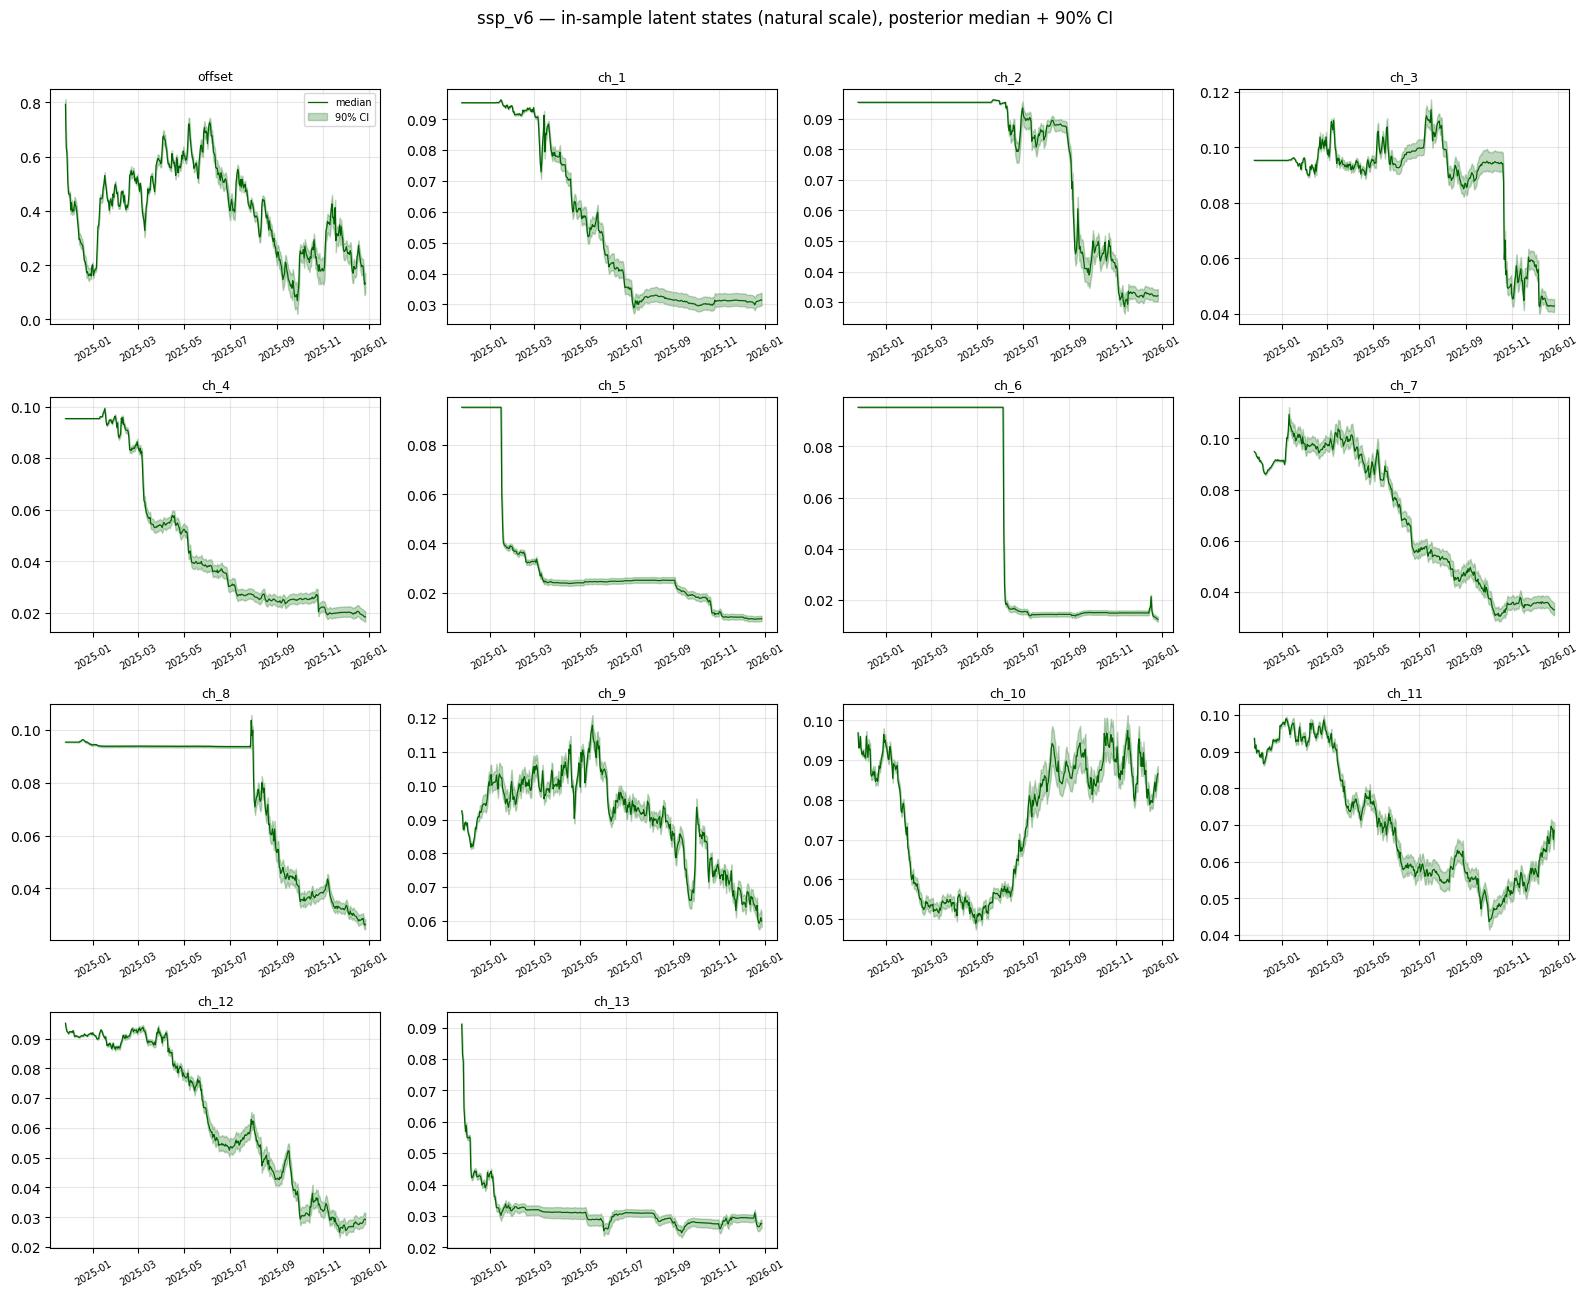

In [ ]:
fig, axes = plot_states(
    idata,
    dates=train_dates,
    state_labels=state_names,
    states_key="at_nat",
    title="ssp_v6 — in-sample latent states (natural scale), posterior median + 90% CI",
)
plt.show()


## Future Design Matrix

`build_forecast_design` resolves every column of `Z_train` by one of three rules — periodic
continuation, supplied future covariate, or constant carry-forward. This design has no explicit periodic
dummy block (the weekly / yearly seasonality is folded into the single `offset` column), and every column
moves over time, so all of them arrive as **known future covariates**: media spend that is already
planned, plus the deterministic trend/seasonality offset. A design built from seasonal dummies would pass
`periodic={"columns": ..., "period": 7}` instead and let the helper continue the cycle.


In [ ]:
Z_future = build_forecast_design(
    np.asarray(Z),
    HORIZON,
    covariates_future=Z_future_truth,   # (horizon, n_series, n_states) -> fills every column
)

print("Z_future shape:", Z_future.shape, "(horizon, n_series, n_states)")
print("matches the withheld design:", np.allclose(Z_future, Z_future_truth))


Z_future shape: (28, 14, 14) (horizon, n_series, n_states)
matches the withheld design: True


## Forecast

Two calls, same seed: `noise_embed=False` gives the **mean path** `mu` (state uncertainty only), and
`noise_embed=True` adds the per-step observation draw `eps ~ N(0, sigma_h**2)` on top. The first widens
with the horizon because of the random walk; the second is that band plus a horizon-flat noise slab.


In [ ]:
fc_mu = forecast_ssp(idata, Z_future, noise_embed=False, seed=SEED)
fc_y = forecast_ssp(idata, Z_future, noise_embed=True, seed=SEED)

print(fc_y)
print()
print("forecast_samples shape:", fc_y["forecast_samples"].shape, "= (n_sample, horizon, n_series)")


<xarray.Dataset> Size: 4MB
Dimensions:           (sample: 400, time: 28, series: 14)
Coordinates:
  * sample            (sample) int64 3kB 0 1 2 3 4 5 ... 394 395 396 397 398 399
  * time              (time) int64 224B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27
  * series            (series) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    mu_samples        (sample, time, series) float64 1MB 0.8618 ... 0.4949
    eps_samples       (sample, time, series) float64 1MB 0.1534 ... -0.112
    forecast_samples  (sample, time, series) float64 1MB 1.015 ... 0.3829

forecast_samples shape: (400, 28, 14) = (n_sample, horizon, n_series)


In [ ]:
# Everything below is plotted on the ORIGINAL response scale: undo y = y_raw / y_scale.
def to_orig(samples: np.ndarray) -> np.ndarray:
    """Undo the per-series mean normalisation on a (sample, time, series) array."""
    return samples * y_scale[None, None, :]


f_mu = to_orig(fc_mu["forecast_samples"].values)     # (sample, horizon, series)
f_y = to_orig(fc_y["forecast_samples"].values)

# In-sample fitted mean, flattened over (chain, draw).
mu_insample = np.asarray(mcmc.get_samples()["mu"]) * y_scale[None, None, :]

q_mu = np.quantile(f_mu, [0.05, 0.25, 0.50, 0.75, 0.95], axis=0)   # (5, horizon, series)
q_y = np.quantile(f_y, [0.05, 0.95], axis=0)
mu_med = np.median(mu_insample, axis=0)                            # (n_steps, series)

print("median forecast (series 0), first 5 steps:", np.round(q_mu[2, :5, 0], 3))


median forecast (series 0), first 5 steps: [3.488 3.929 4.226 3.526 2.7  ]


### Plot 1 — Forecast Fan Chart, One Series


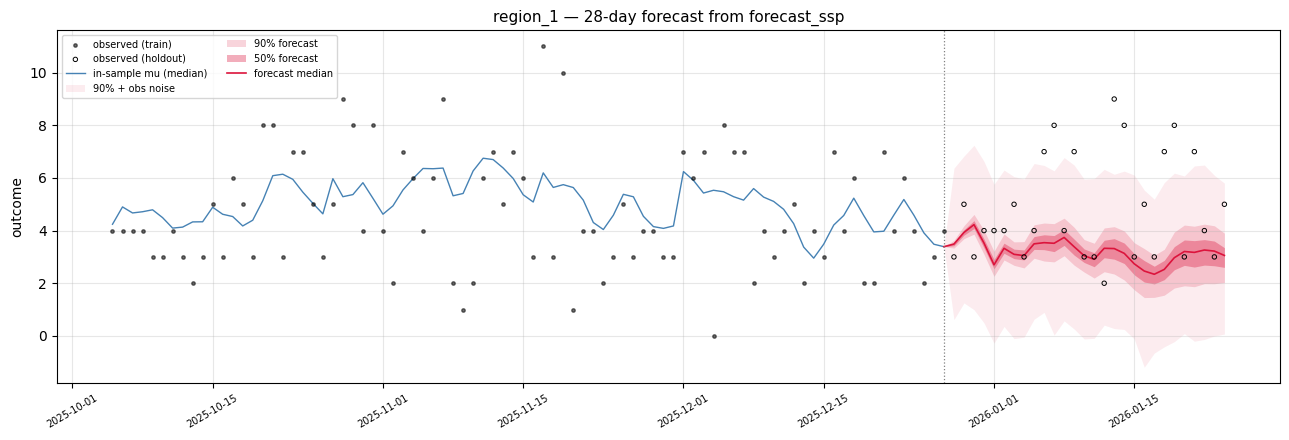

In [ ]:
def plot_fan(ax, j, lookback=84, legend=False):
    """Fan chart for series `j`: in-sample fit, then the forecast bands, joined at the seam."""
    hist = slice(n_train - lookback, n_train)
    seam_date = train_dates[-1]

    # Prepend the last in-sample point to every forecast line so the seam is drawn, not implied.
    fdates = np.concatenate([[seam_date], future_dates])

    def joined(arr, seam_value):
        return np.concatenate([[seam_value], arr])

    ax.scatter(train_dates[hist], y_raw[hist, j], s=6, color="black", alpha=0.55,
               label="observed (train)", zorder=3)
    ax.scatter(future_dates, y_raw[n_train:, j], s=10, facecolors="none", edgecolors="black",
               linewidths=0.7, label="observed (holdout)", zorder=3)
    ax.plot(train_dates[hist], mu_med[hist, j], color="steelblue", linewidth=1.0,
            label="in-sample mu (median)")

    seam = mu_med[n_train - 1, j]
    ax.fill_between(fdates, joined(q_y[0, :, j], seam), joined(q_y[1, :, j], seam),
                    color="crimson", alpha=0.08, linewidth=0, label="90% + obs noise")
    ax.fill_between(fdates, joined(q_mu[0, :, j], seam), joined(q_mu[4, :, j], seam),
                    color="crimson", alpha=0.18, linewidth=0, label="90% forecast")
    ax.fill_between(fdates, joined(q_mu[1, :, j], seam), joined(q_mu[3, :, j], seam),
                    color="crimson", alpha=0.35, linewidth=0, label="50% forecast")
    ax.plot(fdates, joined(q_mu[2, :, j], seam), color="crimson", linewidth=1.2,
            label="forecast median")

    ax.axvline(seam_date, color="grey", linestyle=":", linewidth=0.9)
    ax.set_title(dmas[j], fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    if legend:
        ax.legend(fontsize=7, loc="upper left", ncol=2)


fig, ax = plt.subplots(figsize=(13, 4.5))
plot_fan(ax, 0, legend=True)
ax.set_title(f"{dmas[0]} — {HORIZON}-day forecast from forecast_ssp", fontsize=11)
ax.set_ylabel(response)
plt.tight_layout()
plt.show()


Two properties the chart has to show, checked numerically rather than by eye:

- **The bands widen with the horizon.** The mean path is a random walk from `a_T`, so its variance grows
  linearly in `h`. On the real `Z_future` the width also moves with the covariates, so monotonicity is
  measured on a *frozen* design (every future row equal to the first), which isolates the random-walk
  growth. The noise-inflated band does *not* visibly widen here — on this daily, spiky panel the fitted
  `sigma_h` is an order of magnitude above the random-walk spread, so it dominates the outer envelope.
  (`tests/test_ssp_forecast_e2e.py` draws the same distinction.)
- **The median joins the in-sample fit at the seam.** Forecast step 0 is `Z_future[0] @ a_nat(a_T + eta_1)`
  while the last in-sample step is `Z[-1] @ a_nat(a_T)` — same state, one noise increment apart — so the
  jump at the seam must be small next to the day-to-day movement of `mu` itself.


In [ ]:
# Band widening: the 5-95% width of the mean path, per horizon step, averaged over series.
width_mu = (q_mu[4] - q_mu[0]).mean(axis=1)     # (horizon,)
width_y = (q_y[1] - q_y[0]).mean(axis=1)

print(f"mu band width       h=1: {width_mu[0]:.3f}   h={HORIZON}: {width_mu[-1]:.3f}"
      f"   ratio: {width_mu[-1] / width_mu[0]:.2f}x")
print(f"+ obs-noise width   h=1: {width_y[0]:.3f}   h={HORIZON}: {width_y[-1]:.3f}"
      f"   ratio: {width_y[-1] / width_y[0]:.2f}x")

# On the real design the band also moves with the covariates, which change step to step. Freezing the
# design at its first future row isolates the random-walk variance growth, which must be monotone.
fc_frozen = forecast_ssp(idata, np.repeat(Z_future[:1], HORIZON, axis=0), noise_embed=False, seed=SEED)
var_frozen = fc_frozen["mu_samples"].var(dim="sample").values      # (horizon, series)
print("frozen design -- variance nondecreasing in horizon for every series:",
      bool(np.all(np.diff(var_frozen, axis=0) >= -1e-12)),
      f"| var grows {float(var_frozen[-1].mean() / var_frozen[0].mean()):.1f}x over the horizon")

# Seam continuity: |first forecast median - last in-sample median| against the typical daily |diff| of mu.
seam_gap = np.abs(q_mu[2, 0, :] - mu_med[n_train - 1, :])
daily_step = np.abs(np.diff(mu_med, axis=0)).mean(axis=0)
print(f"\nseam gap / typical daily step -- median {np.median(seam_gap / daily_step):.2f}, "
      f"max {np.max(seam_gap / daily_step):.2f}")


mu band width       h=1: 0.234   h=28: 1.471   ratio: 6.30x
+ obs-noise width   h=1: 4.803   h=28: 5.011   ratio: 1.04x
frozen design -- variance nondecreasing in horizon for every series: True | var grows 26.0x over the horizon

seam gap / typical daily step -- median 0.33, max 2.12


### Plot 3 — Multi-Series Panel

`forecast_samples` is `(sample, time, series)`, so the same fan chart facets straight across the panel:
one call to `forecast_ssp`, one subplot per series.


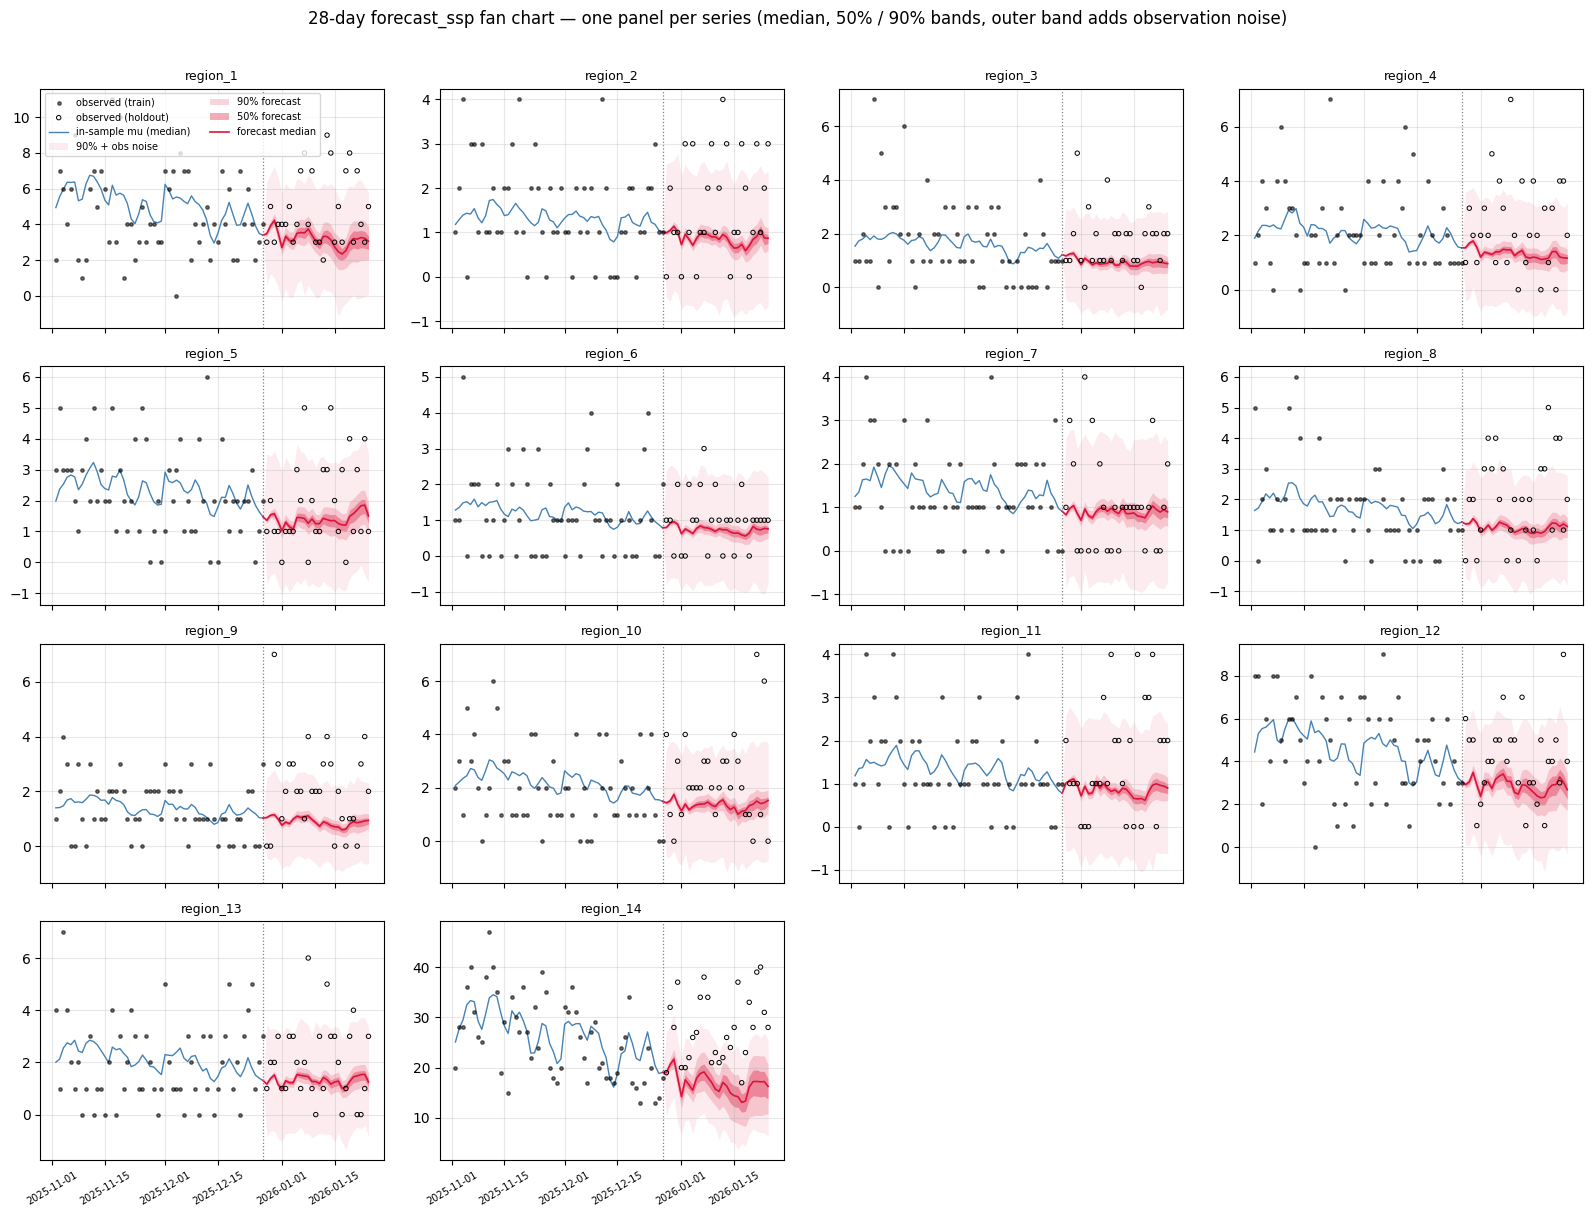

In [ ]:
n_cols = 4
n_rows = int(np.ceil(n_series / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.0 * n_rows), sharex=True)
axes = axes.flatten()

for j in range(n_series):
    plot_fan(axes[j], j, lookback=56, legend=(j == 0))

for ax in axes[n_series:]:
    ax.set_visible(False)

fig.suptitle(
    f"{HORIZON}-day forecast_ssp fan chart — one panel per series "
    "(median, 50% / 90% bands, outer band adds observation noise)",
    y=1.01,
)
plt.tight_layout()
plt.show()


### Holdout Coverage


In [ ]:
lo_y, hi_y = q_y[0], q_y[1]
lo_mu, hi_mu = q_mu[0], q_mu[4]
holdout = y_raw[n_train:]                       # original scale, never seen by the filter

cov_y = ((holdout >= lo_y) & (holdout <= hi_y)).mean()
cov_mu = ((holdout >= lo_mu) & (holdout <= hi_mu)).mean()
mae = np.abs(q_mu[2] - holdout).mean()

print(f"holdout inside the 90% predictive band (with obs noise): {cov_y:.1%}")
print(f"holdout inside the 90% mean-path band:                   {cov_mu:.1%}")
print(f"median-forecast MAE: {mae:.3f}   vs mean |y| baseline: {np.abs(holdout).mean():.3f}")


holdout inside the 90% predictive band (with obs noise): 76.5%
holdout inside the 90% mean-path band:                   19.6%
median-forecast MAE: 1.936   vs mean |y| baseline: 4.023


## Notes

- **Is a `plot_forecast` helper worth a follow-up issue?** Yes. `plot_fan` above is ~30 lines of
  quantile-and-`fill_between` bookkeeping that every SSP forecast will repeat: joining the forecast at the
  seam, stacking nested bands, faceting `(sample, time, series)` over the series axis, and undoing the
  per-series normalisation. The pieces that are genuinely notebook-specific are only the back-transform
  and the choice of history window. A `plot_forecast(forecast, observed=..., insample_mu=..., dates=...)`
  in `bunobee.models.ssp.plotting`, shaped like the existing `plot_states`, would cover charts 1 and 3
  here (single axis vs. faceted panel) — worth filing separately rather than widening the scope of the
  `forecast_ssp` work.
- The predictive band on this dataset is dominated by `sigma_h`, not by state uncertainty. That is a
  property of the daily sparse panel, not of `forecast_ssp`: plot `mu_samples` to see the state
  uncertainty on its own, as the fan chart above does.
- All 14 design columns are supplied as known future covariates here. Where the future covariate path is
  itself uncertain, that uncertainty is *not* propagated — `Z_future` enters as a fixed matrix.
